In [1]:
# Name: Leonard Nkholise 
# Date: 28 December 2021
# Updated By: 13 Nov 2024
# Datasource link: https://royalsocietypublishing.org/doi/10.1098/rspb.2018.2400

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn import preprocessing
from sklearn.model_selection import train_test_split

from matplotlib.colors import ListedColormap

# 2.0 Data Reading & Handling 

### 2.1 Read and assign filtered .csv data into program 

- Longipes were regarded as desirable primary examples for this section and thus were added and used through out the procedure.
- Longipes can be interchanged with americana and pulchella species as they all posses distinctions of both male and female in their recorded data unlike other species.

In [3]:
# Loading the data :
c_data = pd.read_csv("../data/Allometry_all microvelia species.csv")

In [4]:
# Let's see how it looks : 
c_data[c_data["Species"]=="longipes"]

,Individuals,Species,Sexe,wing_morph,Total leg length 3,body length
42,66,longipes,M,wingless,5877.653000,1955.072000
43,68,longipes,M,wingless,5225.772000,1895.612000
44,69,longipes,M,wingless,5840.742000,1960.864000
45,70,longipes,M,wingless,6012.491000,1964.802000
46,71,longipes,M,wingless,7451.682000,2089.121000
...,...,...,...,...,...,...
268,129,longipes,F,wingless,2662.044374,2080.895224
269,130,longipes,F,wingless,2706.456149,2113.664610
270,131,longipes,F,wingless,3053.442015,2262.229024
271,132,longipes,F,wingless,2697.001779,2109.554107


In [5]:
#can change to americana,pulchella and longipes species
species ="pulchella"
c_data=c_data[c_data["Species"]==f"{species}"] 
x_data = c_data.iloc[:,[4,5]].values
y_data = c_data.loc[:,"Sexe"].values
x_data.shape

(62, 2)

### 2.2 Label encoding for male and female variants of species

In [6]:
#Label encoding for male and female
lab_enc=preprocessing.LabelEncoder()
y_data = lab_enc.fit_transform(y_data).reshape(-1,1)
y_data.shape

(62, 1)

### 2.3 Data splitting and Logistic regression training on data

In [7]:
#splitting data into training and test sets
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data, test_size = 0.43, random_state=0)
x_original= x_train

In [8]:
#Feature scaling for total leg length and body length to avoid data skewing in one scale over the other 
sc = preprocessing.StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
x_train_og = sc.inverse_transform(x_train)


# 3.0 Model fitting & comparison 

### 3.1 Logistic Regression vs Support Vector Machine (SVM)

Here, we fit and compare **Logistic Regression** and **SVM** models to classify male and female categories. Logistic Regression provides a linear boundary, while SVM with an RBF kernel handles complex overlaps, mapping data to a higher dimension. We evaluate each model’s accuracy to determine the best fit for our dataset.

In [9]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
log_reg = LogisticRegression(solver='lbfgs', random_state=0)
log_reg.fit(x_train, y_train.ravel())
y_pred_lr = log_reg.predict(x_test)

# SVM
from sklearn.svm import SVC
svc = SVC(kernel='rbf', gamma='auto', random_state=0)
svc.fit(x_train, y_train.ravel())
y_pred_svc = svc.predict(x_test)

print('\n Logistic Regression accuracy:{:.2f}'.format(log_reg.score(x_test,y_test)))
print('\n SVM accuracy:{:.2f}\n'.format(svc.score(x_test,y_test)))


 Logistic Regression accuracy:1.00

 SVM accuracy:1.00



In [10]:
# Set up a mesh for plotting decision boundaries
x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))


# Predict on mesh grid for decision boundary
Z_log_reg = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svc = svc.predict(np.c_[xx.ravel(), yy.ravel()])

# Reshape the predictions back into the mesh shape
Z_log_reg = Z_log_reg.reshape(xx.shape)
Z_svc = Z_svc.reshape(xx.shape)

# Scale the mesh grid points back to the original feature space for visualization
xx_original, yy_original = sc.inverse_transform(np.c_[xx.ravel(), yy.ravel()]).T
xx_original = xx_original.reshape(xx.shape)
yy_original = yy_original.reshape(yy.shape)

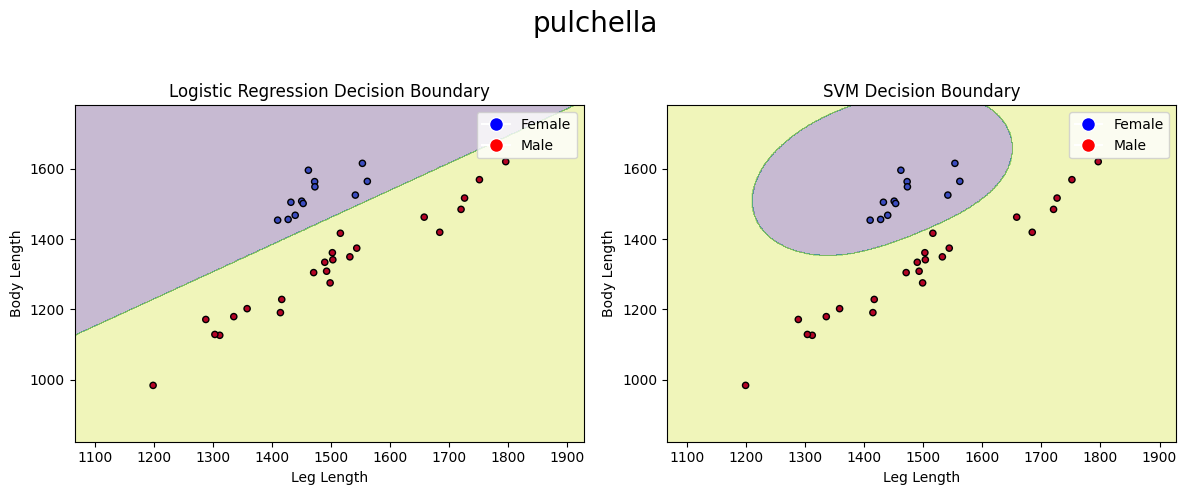

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Decision Boundary
axes[0].contourf(xx_original, yy_original, Z_log_reg, alpha=0.3)
axes[0].scatter(x_train_og[:, 0], x_train_og[:, 1], c=y_train, edgecolor='k', s=20, cmap='coolwarm')
axes[0].set_title("Logistic Regression Decision Boundary")
axes[0].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Female'),
                       plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Male')],
               loc='upper right')

# SVM Decision Boundary
axes[1].contourf(xx_original, yy_original, Z_svc, alpha=0.3)
axes[1].scatter(x_train_og[:, 0], x_train_og[:, 1], c=y_train, edgecolor='k', s=20, cmap='coolwarm')
axes[1].set_title("SVM Decision Boundary")
axes[1].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Female'),
                       plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Male')],
               loc='upper right')

# Add labels for x and y axes
axes[0].set_xlabel('Leg Length')
axes[0].set_ylabel('Body Length')
axes[1].set_xlabel('Leg Length')
axes[1].set_ylabel('Body Length')

# Add the species name as the main title
fig.suptitle(f"{species}", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit suptitle

# Uncomment if you want to save the figure
# fig.savefig(f"{species}.png", dpi=300, bbox_inches='tight')

plt.show()


# Conclusion

The successful classification of male and female water striders based on leg and body length using both ***Logistic Regression*** and ***SVM*** suggests a strong physical distinction clearly linked to mating behavior. For this project, it means these models can reliably separate genders based on these traits, enabling us to explore how these physical differences influence mating patterns and behaviors in water striders. Logistic Regression provides clear interpretability, while SVM offers adaptability, giving us robust tools to deepen our understanding of gender-based physical and behavioral dynamics in this species.